# Hospital Deterioration — Next-12h Advanced Early Warning Baseline
Compact, production-oriented baseline for predicting clinical deterioration in the next 12 hours.

## Overview & Goals

This notebook builds a pragmatic baseline model for the `deterioration_next_12h` label, designed to plug directly into dashboards and alert simulators.

We will:

- Load the ML-ready patient-level table `hospital_deterioration_ml_ready.csv`.
- Optionally enrich it with simple temporal features derived from `vitals_timeseries.csv` and `labs_timeseries.csv`.
- Train and compare **Logistic Regression**, **HistGradientBoosting**, and (optionally) **XGBoost**.
- Build a small **ensemble** from the strongest base models.
- Evaluate performance with ROC AUC and PR AUC on a held-out test set.
- Explore **operating thresholds and alert policies** under different FN/FP cost settings.
- Export model artifacts and policy tables for downstream dashboards or scenario simulations.


## 1. Config & imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix,
)

import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Global config
RANDOM_STATE = 42
DATA_DIR = Path('data/raw')
ARTIFACT_DIR = Path('artifacts')

def find_data_file(filename: str) -> Path:
    """Resolve a dataset file from local repo paths or Kaggle inputs."""
    candidates = [DATA_DIR / filename, Path(filename)]
    for p in candidates:
        if p.exists():
            return p
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        for d in kaggle_root.iterdir():
            if d.is_dir():
                p1 = d / filename
                if p1.exists():
                    return p1
                p2 = d / 'data' / filename
                if p2.exists():
                    return p2
    raise FileNotFoundError(
        f"Could not find {filename}. Place it under data/raw/ or adjust paths in the notebook."
    )
TARGET_COL = "deterioration_next_12h"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print(f"[INFO] XGBoost available: {HAS_XGB}")


[INFO] XGBoost available: True


## 2. Data loading & basic info

In [ ]:
ml_path = find_data_file('hospital_deterioration_ml_ready.csv')
ml = pd.read_csv(ml_path)

print("[SHAPE]", ml.shape)
print("[COLUMNS]", len(ml.columns))

# Target distribution
y = ml[TARGET_COL].astype(int)
print("\n[TARGET] positive windows:")
print(y.value_counts())
print(f"Base rate: {y.mean():.4f} ({y.mean() * 100:.2f}%)")

# Lightweight schema / numeric sanity check
print("\n[INFO] dtypes summary:")
print(ml.dtypes.value_counts())

num_cols_preview = ml.select_dtypes(include=["number"]).columns.tolist()
if num_cols_preview:
    print("\n[NUMERIC] describe (first 10 numeric columns):")
    display(ml[num_cols_preview].describe().T.head(10))

print("\n[HEAD] sample rows:")
display(ml.head())


FileNotFoundError: [Errno 2] No such file or directory: 'hospital_deterioration_ml_ready.csv'

## 3. Optional temporal features from vitals and labs

We optionally enrich the ML-ready table with short-window summaries derived from `vitals_timeseries.csv` and `labs_timeseries.csv`.

For each patient-hour, we compute:

- Rolling means over the last **3 hours** for selected vital signs and lab results.
- Simple hour-to-hour deltas: **current − previous hour**.

These temporal features are joined back to the ML table using:
- `patient_id`
- `hour_from_admission`

If either of these keys is missing from the ML table, the temporal enrichment step is **skipped safely**, and the notebook falls back to a purely tabular baseline.

> Note: these are intentionally simple temporal features, meant as a lightweight starting point rather than a full clinical feature engineering pipeline.


In [ ]:

USE_TEMPORAL_FEATURES = True  # Set to False for a purely tabular baseline
TEMP_WINDOW_HOURS = 3

def add_window_features(df, group_cols, value_cols, window=3, prefix="v"):
    """
    For each value column:
      - rolling mean over the last `window` rows (per group)
      - simple delta vs previous row (per group)
    """
    out = df.copy()
    for col in value_cols:
        # Rolling mean over last `window` hours (uses only past and current)
        out[f"{prefix}_{col}_mean_{window}h"] = (
            out.groupby(group_cols)[col]
            .rolling(window=window, min_periods=1)
            .mean()
            .reset_index(level=group_cols, drop=True)
        )
        # Simple delta vs previous hour
        out[f"{prefix}_{col}_delta_1h"] = out.groupby(group_cols)[col].diff()
    return out


if USE_TEMPORAL_FEATURES:
    vitals_path = find_data_file('vitals_timeseries.csv')
    labs_path = find_data_file('labs_timeseries.csv')

    if vitals_path.exists() and labs_path.exists():
        vitals = pd.read_csv(vitals_path)
        labs = pd.read_csv(labs_path)

        base_cols = ["patient_id", "hour_from_admission"]
        vitals = vitals.sort_values(base_cols)
        labs = labs.sort_values(base_cols)

        vitals_feat = add_window_features(
            vitals,
            group_cols=["patient_id"],
            value_cols=["heart_rate", "respiratory_rate", "spo2_pct", "systolic_bp"],
            window=TEMP_WINDOW_HOURS,
            prefix="v",
        )

        labs_feat = add_window_features(
            labs,
            group_cols=["patient_id"],
            value_cols=["lactate", "wbc_count", "creatinine"],
            window=TEMP_WINDOW_HOURS,
            prefix="l",
        )

        vitals_feat = vitals_feat[
            ["patient_id", "hour_from_admission"]
            + [c for c in vitals_feat.columns if c.startswith("v_")]
        ]
        labs_feat = labs_feat[
            ["patient_id", "hour_from_admission"]
            + [c for c in labs_feat.columns if c.startswith("l_")]
        ]

        panel_key = ["patient_id", "hour_from_admission"]
        if all(k in ml.columns for k in panel_key):
            ml = (
                ml.merge(vitals_feat, on=panel_key, how="left")
                  .merge(labs_feat, on=panel_key, how="left")
            )
            print("[TEMPORAL] Added temporal features from vitals and labs.")
        else:
            print("[TEMPORAL] Skipped: ML table has no patient_id/hour_from_admission keys.")
    else:
        print("[TEMPORAL] Skipped: vitals_timeseries.csv / labs_timeseries.csv not found.")
else:
    print("[TEMPORAL] Skipped by configuration.")

print("[SHAPE after temporal merge]", ml.shape)

# Safety: any NaNs introduced by temporal features / merges are set to 0.0
ml = ml.fillna(0.0)


[TEMPORAL] Skipped: ML table has no patient_id/hour_from_admission keys.
[SHAPE after temporal merge] (417866, 22)


## 4. Feature schema & preprocessing

In [5]:
# Identify ID-like columns that should not be used as features
id_cols = [c for c in ["patient_id", "hour_from_admission"] if c in ml.columns]

# All feature columns = everything except IDs and target
feature_cols = [
    c for c in ml.columns
    if c not in id_cols + [TARGET_COL]
]

X = ml[feature_cols].copy()
y = ml[TARGET_COL].astype(int).copy()

# Basic feature type split
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("[ID COLS]", id_cols)
print("[N FEATURES]", len(feature_cols))
print("[CATEGORICAL COLS]", cat_cols)
print("[NUMERIC COLS]", len(num_cols))

# Preprocessing blocks
numeric_scaler = StandardScaler()

# Handle scikit-learn version differences for dense output
try:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    # For older scikit-learn versions
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

# For linear models: scale numeric + one-hot encode categorical
preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_scaler, num_cols),
        ("cat", categorical_encoder, cat_cols),
    ]
)

# For tree-based models: pass numeric as-is + one-hot encode categorical
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", categorical_encoder, cat_cols),
    ]
)


NameError: name 'ml' is not defined

## 5. Train / test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"[SPLIT] Train: {X_train.shape}, Test: {X_test.shape}")
print(f"[TRAIN POS RATE] {y_train.mean():.4f}")
print(f"[TEST POS RATE]  {y_test.mean():.4f}")

[SPLIT] Train: (313399, 20), Test: (104467, 20)
[TRAIN POS RATE] 0.0541
[TEST POS RATE]  0.0541


## 6. Baseline models (Logistic, HGB, XGBoost)

In [ ]:

# Linear baseline
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
)

# Tree-based baseline
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=None,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)

# Pipelines: preprocessing + model
log_reg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_linear),
        ("model", log_reg),
    ]
)

hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_tree),
        ("model", hgb),
    ]
)

# Optional advanced tree model
if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_pipe = Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", xgb),
        ]
    )
else:
    xgb_pipe = None


### 6.1 Cross‑validation on the training set

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

def cv_scores(name, estimator):
    """
    Run Stratified K-Fold CV and report ROC AUC and PR AUC.
    """
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1,
    )
    print(f"\n[CV] {name}")
    print(f"ROC AUC: {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"PR AUC:  {scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}")
    return scores

cv_results = {}
cv_results["log_reg"] = cv_scores("Logistic Regression", log_reg_pipe)
cv_results["hgb"] = cv_scores("HistGradientBoosting", hgb_pipe)
if xgb_pipe is not None:
    cv_results["xgb"] = cv_scores("XGBoost", xgb_pipe)



[CV] LogisticRegression
ROC AUC: 0.8067 ± 0.0016
PR AUC:  0.2444 ± 0.0024

[CV] HistGradientBoosting
ROC AUC: 0.9403 ± 0.0025
PR AUC:  0.6453 ± 0.0114

[CV] XGBoost
ROC AUC: 0.9517 ± 0.0029
PR AUC:  0.6883 ± 0.0100


### 6.2 Fit models on full training set & evaluate on test

In [ ]:
# Fit base models on the full training split
log_reg_pipe.fit(X_train, y_train)
hgb_pipe.fit(X_train, y_train)
if xgb_pipe is not None:
    xgb_pipe.fit(X_train, y_train)

def eval_model(name, pipe):
    """
    Evaluate a fitted pipeline on the test set using ROC AUC and PR AUC.
    """
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    print(f"[TEST] {name:<20} | ROC AUC = {auc:.4f} | PR AUC = {ap:.4f}")
    return proba, auc, ap

proba_log, auc_log, ap_log = eval_model("Logistic Regression", log_reg_pipe)
proba_hgb, auc_hgb, ap_hgb = eval_model("HistGradientBoosting", hgb_pipe)

if xgb_pipe is not None:
    proba_xgb, auc_xgb, ap_xgb = eval_model("XGBoost", xgb_pipe)
else:
    proba_xgb = None


[TEST] LogisticRegression | ROC AUC = 0.8101 | PR AUC = 0.2465
[TEST] HistGradientBoosting | ROC AUC = 0.9402 | PR AUC = 0.6455
[TEST] XGBoost | ROC AUC = 0.9519 | PR AUC = 0.6909


### 6.3 Simple ensemble (average of base models)

In [ ]:
probas = [proba_hgb, proba_log]

if proba_xgb is not None:
    probas.append(proba_xgb)

# Simple average ensemble over available base models
ensemble_proba = np.mean(probas, axis=0)

auc_ens = roc_auc_score(y_test, ensemble_proba)
ap_ens = average_precision_score(y_test, ensemble_proba)
print(f"[TEST] { 'Ensemble':>20s} | ROC AUC = {auc_ens:.4f} | PR AUC = {ap_ens:.4f}")


[TEST] Ensemble | ROC AUC = 0.9096 | PR AUC = 0.6263


## 7. ROC & Precision–Recall curves


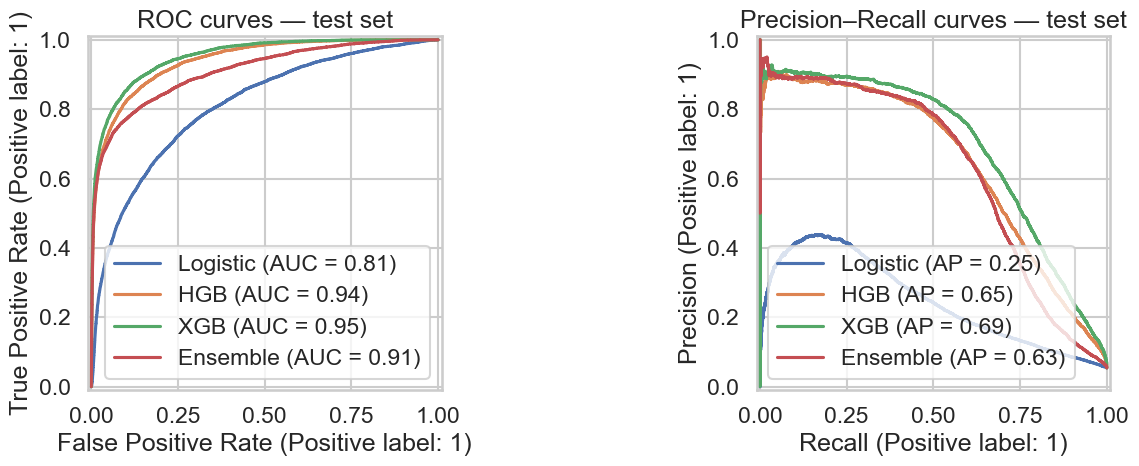

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC curves ---
RocCurveDisplay.from_predictions(
    y_test,
    proba_log,
    name="Logistic",
    ax=axes[0],
)
RocCurveDisplay.from_predictions(
    y_test,
    proba_hgb,
    name="HistGB",
    ax=axes[0],
)
if proba_xgb is not None:
    RocCurveDisplay.from_predictions(
        y_test,
        proba_xgb,
        name="XGBoost",
        ax=axes[0],
)
RocCurveDisplay.from_predictions(
    y_test,
    ensemble_proba,
    name="Ensemble",
    ax=axes[0],
)

axes[0].plot([0, 1], [0, 1], "--", linewidth=1)
axes[0].set_title("ROC curves — test set")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")

# --- Precision–Recall curves ---
PrecisionRecallDisplay.from_predictions(
    y_test,
    proba_log,
    name="Logistic",
    ax=axes[1],
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    proba_hgb,
    name="HistGB",
    ax=axes[1],
)
if proba_xgb is not None:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        proba_xgb,
        name="XGBoost",
        ax=axes[1],
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    ensemble_proba,
    name="Ensemble",
    ax=axes[1],
)

axes[1].set_title("Precision–Recall curves — test set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()


## 8. Threshold & cost-based alert policies


[POLICY] Balanced cost (FN=5, FP=1) — best few rows


,threshold,precision,recall,fpr,alert_rate,cost,tp,fp,fn,tn
5,0.35,0.543192,0.664778,0.031947,0.066155,12622.0,3754,3157,1893,95663
6,0.40,0.643747,0.613423,0.019399,0.051509,12832.0,3464,1917,2183,96903
7,0.45,0.713551,0.565079,0.012963,0.042808,13561.0,3191,1281,2456,97539
4,0.30,0.418713,0.718789,0.057023,0.092795,13575.0,4059,5635,1588,93185
8,0.50,0.765852,0.521870,0.009118,0.036835,14401.0,2947,901,2700,97919



[POLICY] High-recall (FN=15, FP=1) — best few rows


,threshold,precision,recall,fpr,alert_rate,cost,tp,fp,fn,tn
4,0.30,0.418713,0.718789,0.057023,0.092795,29455.0,4059,5635,1588,93185
3,0.25,0.285964,0.781123,0.111455,0.147654,29554.0,4411,11014,1236,87806
5,0.35,0.543192,0.664778,0.031947,0.066155,31552.0,3754,3157,1893,95663
2,0.20,0.184092,0.845936,0.214248,0.248394,34222.0,4777,21172,870,77648
6,0.40,0.643747,0.613423,0.019399,0.051509,34662.0,3464,1917,2183,96903



[POLICY] Low-alerts (FN=5, FP=2) — best few rows


,threshold,precision,recall,fpr,alert_rate,cost,tp,fp,fn,tn
6,0.40,0.643747,0.613423,0.019399,0.051509,14749.0,3464,1917,2183,96903
7,0.45,0.713551,0.565079,0.012963,0.042808,14842.0,3191,1281,2456,97539
8,0.50,0.765852,0.521870,0.009118,0.036835,15302.0,2947,901,2700,97919
5,0.35,0.543192,0.664778,0.031947,0.066155,15779.0,3754,3157,1893,95663
9,0.55,0.800000,0.476713,0.006810,0.032211,16121.0,2692,673,2955,98147


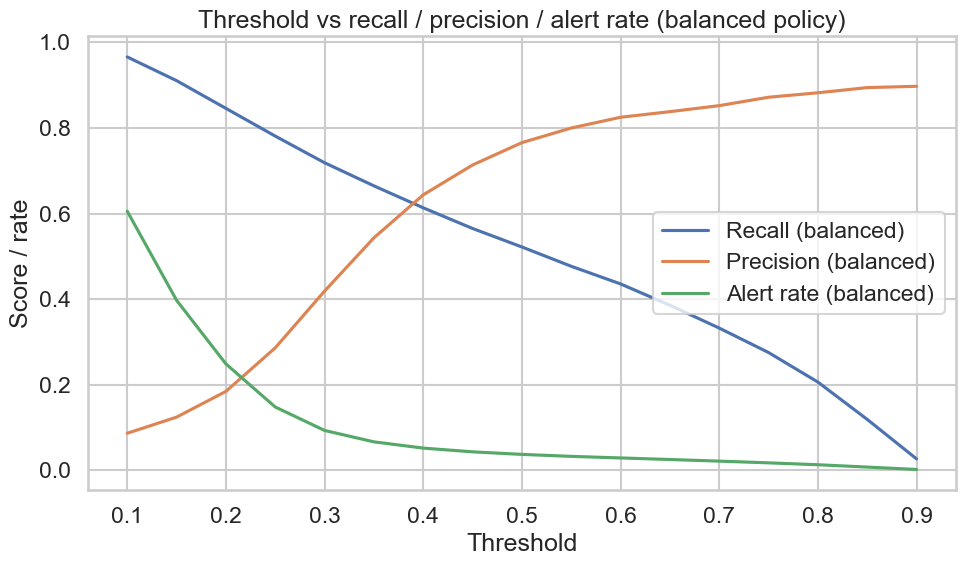

In [ ]:
# Use ensemble scores as the default policy signal
y_score = ensemble_proba

def threshold_table(y_true, y_score, thresholds, cost_fn=10.0, cost_fp=1.0):
    """
    Build a policy table over a grid of thresholds, computing:
      - precision, recall, false positive rate
      - alert rate (fraction of windows that trigger an alert)
      - simple cost: cost_fn * FN + cost_fp * FP
    """
    rows = []
    for th in thresholds:
        y_pred = (y_score >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        alert_rate = (tp + fp) / len(y_true)
        cost = cost_fn * fn + cost_fp * fp

        rows.append(
            {
                "threshold": th,
                "precision": precision,
                "recall": recall,
                "fpr": fpr,
                "alert_rate": alert_rate,
                "cost": cost,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )
    return pd.DataFrame(rows)


# Threshold grid to explore
thresholds = np.linspace(0.1, 0.9, 17)

policy_balanced = threshold_table(
    y_true=y_test,
    y_score=y_score,
    thresholds=thresholds,
    cost_fn=5.0,
    cost_fp=1.0,
)

policy_high_recall = threshold_table(
    y_true=y_test,
    y_score=y_score,
    thresholds=thresholds,
    cost_fn=15.0,
    cost_fp=1.0,
)

policy_low_alerts = threshold_table(
    y_true=y_test,
    y_score=y_score,
    thresholds=thresholds,
    cost_fn=5.0,
    cost_fp=2.0,
)

print("[POLICY] Balanced cost (FN=5, FP=1) — best few rows")
display(policy_balanced.sort_values("cost").head())

print("\n[POLICY] High-recall (FN=15, FP=1) — best few rows")
display(policy_high_recall.sort_values("cost").head())

print("\n[POLICY] Low-alerts (FN=5, FP=2) — best few rows")
display(policy_low_alerts.sort_values("cost").head())

# Simple visualization for the balanced policy
plt.figure(figsize=(10, 6))
plt.plot(policy_balanced["threshold"], policy_balanced["recall"], label="Recall (balanced)")
plt.plot(policy_balanced["threshold"], policy_balanced["precision"], label="Precision (balanced)")
plt.plot(policy_balanced["threshold"], policy_balanced["alert_rate"], label="Alert rate (balanced)")

plt.xlabel("Threshold")
plt.ylabel("Score / rate")
plt.title("Threshold vs recall / precision / alert rate (balanced policy)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Export artifacts for dashboards / simulations

In [ ]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save ensemble components (downstream code can load one or combine them)
joblib.dump(log_reg_pipe, ARTIFACT_DIR / "model_logreg.pkl")
joblib.dump(hgb_pipe, ARTIFACT_DIR / "model_hgb.pkl")
if xgb_pipe is not None:
    joblib.dump(xgb_pipe, ARTIFACT_DIR / "model_xgb.pkl")

# Save policy tables for different operating regimes
policy_balanced.to_csv(ARTIFACT_DIR / "policy_thresholds_balanced.csv", index=False)
policy_high_recall.to_csv(ARTIFACT_DIR / "policy_thresholds_high_recall.csv", index=False)
policy_low_alerts.to_csv(ARTIFACT_DIR / "policy_thresholds_low_alerts.csv", index=False)

print(f"[SAVE] Models and policy tables saved to: {ARTIFACT_DIR.resolve()}")


[SAVE] Models and policy table saved to: D:\Work\Work\AI Courses\Downloads\Week 0\Hospital Deterioration dataset\artifacts


## 10. Summary & Decisions

This notebook implemented a compact, production-oriented baseline for the `deterioration_next_12h` label, designed to plug directly into dashboards and alert simulators.

In particular, we:

- Loaded the ML-ready table `hospital_deterioration_ml_ready.csv` and inspected basic data health and target balance.
- Optionally enriched the table with simple temporal features from vitals and labs (3-hour rolling means and 1-hour deltas).
- Trained **Logistic Regression**, **HistGradientBoosting**, and (optionally) **XGBoost** using clean preprocessing pipelines.
- Built a simple ensemble of the strongest base models and evaluated performance with ROC AUC and PR AUC on a held-out test set.
- Explored threshold–cost trade-offs via policy tables under different FN/FP cost settings (balanced, high-recall, low-alerts).
- Exported model artifacts and policy tables to an `artifacts/` directory for reuse in dashboards and “what-if” simulators.

### Decisions & takeaways

- The ensemble of tree-based and linear models provides a strong baseline signal for early deterioration risk in the next 12 hours.
- Threshold selection is treated explicitly as a cost trade-off between **missed deteriorations (FN)** and **alarm burden (FP)**, instead of using an arbitrary score cut-off.
- Different clinical contexts (ICU vs ward, high alarm fatigue vs aggressive monitoring) can reuse the same model while choosing different policy profiles (balanced, high-recall, low-alerts).

Use this notebook as a stable, interpretable baseline when iterating on features, models, and alert policies.
